## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

## Download & Save Dataset

In [22]:
import urllib.request

url = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/tox21.csv.gz"
save_path = "../data/raw/tox21.csv.gz"

urllib.request.urlretrieve(url, save_path)


('../data/raw/tox21.csv.gz', <http.client.HTTPMessage at 0x21cddcac950>)

## Load & Preview Data

In [23]:
df = pd.read_csv("../data/raw/tox21.csv.gz")
print(df.shape)
df.head()

(7831, 14)


,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol_id,smiles
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3027,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TOX20800,CC(O)(P(=O)(O)O)P(=O)(O)O


## Missing Values per Target

In [24]:
targets = ['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 
           'NR-ER-LBD', 'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 
           'SR-HSE', 'SR-MMP', 'SR-p53']

print(f"Total molecules: {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")
print("\nMissing values per target:")
print(df[targets].isnull().sum().sort_values(ascending=False))

Total molecules: 7831
Total columns: 14

Missing values per target:
SR-MMP           2021
NR-Aromatase     2010
SR-ARE           1999
NR-ER            1638
NR-PPAR-gamma    1381
SR-HSE           1364
NR-AhR           1282
NR-AR-LBD        1073
SR-p53           1057
NR-ER-LBD         876
SR-ATAD5          759
NR-AR             566
dtype: int64


## Class Imbalance Analysis

In [25]:
print("Positive rate per target (% toxic):")
for t in targets:
    col = df[t].dropna()
    rate = col.mean() * 100
    print(f"  {t:<20} {rate:.1f}%  ({int(col.sum())}/{len(col)} toxic)")

Positive rate per target (% toxic):
  NR-AR                4.3%  (309/7265 toxic)
  NR-AR-LBD            3.5%  (237/6758 toxic)
  NR-AhR               11.7%  (768/6549 toxic)
  NR-Aromatase         5.2%  (300/5821 toxic)
  NR-ER                12.8%  (793/6193 toxic)
  NR-ER-LBD            5.0%  (350/6955 toxic)
  NR-PPAR-gamma        2.9%  (186/6450 toxic)
  SR-ARE               16.2%  (942/5832 toxic)
  SR-ATAD5             3.7%  (264/7072 toxic)
  SR-HSE               5.8%  (372/6467 toxic)
  SR-MMP               15.8%  (918/5810 toxic)
  SR-p53               6.2%  (423/6774 toxic)


## Visualize Class Imbalance

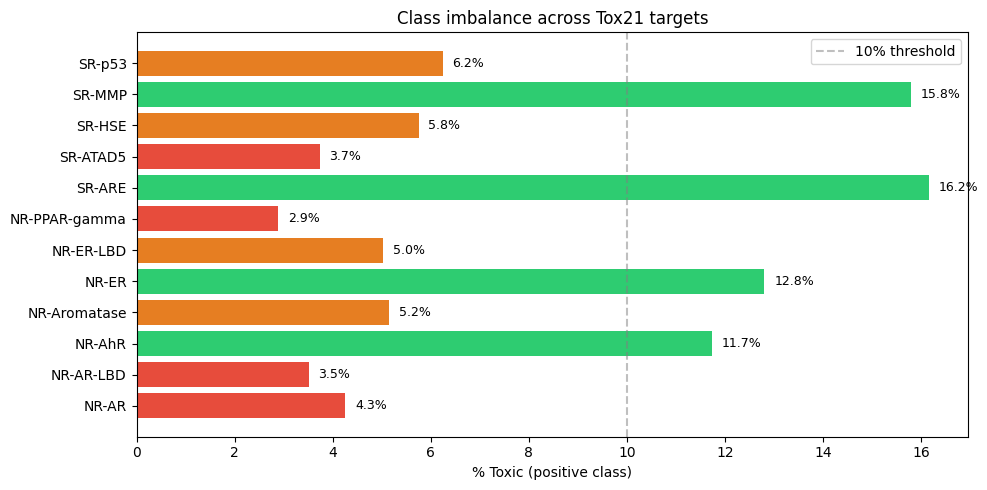

In [28]:
fig, ax = plt.subplots(figsize=(10, 5))

rates = [df[t].mean() * 100 for t in targets]
colors = ['#e74c3c' if r < 5 else '#e67e22' if r < 10 else '#2ecc71' for r in rates]

bars = ax.barh(targets, rates, color=colors)
ax.axvline(x=10, color='gray', linestyle='--', alpha=0.5, label='10% threshold')
ax.set_xlabel("% Toxic (positive class)")
ax.set_title("Class imbalance across Tox21 targets")
ax.legend()

for bar, rate in zip(bars, rates):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{rate:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig("../reports/figures/class_imbalance.png", dpi=150)
plt.show()
